In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
riders=pd.read_csv("riders.csv")
riders.head(5)

,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


In [3]:
batteries=pd.read_csv("batteries.csv")
batteries.head(5)

,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6


In [4]:
city_context=pd.read_csv("city_daily_context.csv")
city_context.head(5)

,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False
3,Bengaluru,2024-01-04,17.9,4.0,2.2,False,False,NaN,False,0.1,False,False
4,Bengaluru,2024-01-05,16.0,7.8,2.0,False,False,NaN,False,0.0,False,False


In [5]:
partners=pd.read_csv("fleet_partners.csv")
partners.head(5)


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,2023-09-01,8.0,NaN,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,2023-05-01,11.0,NaN,NaN,N,30,BLR|PUN|MUM


In [6]:
stations=pd.read_csv("stations.csv")
stations.head(5)

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaN,Launch,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaN,Launch,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [7]:
tickets=pd.read_csv("support_tickets.csv")
tickets.head(5)

,ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score
0,TK-0000001,RD-1001097,STN-BLR-016,NaN,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,NaN,NaN
1,TK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,5.2,NaN
2,TK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,16.3,NaN
3,TK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,high,resolved,4.4,3.0
4,TK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1.0


In [8]:
station_hourly=pd.read_csv("station_hourly_status.csv")
station_hourly.head(5)

,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18,8.2,13.5,92.6,0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18,8.2,11.5,88.0,0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18,8.2,12.9,80.2,0,8.27,ok
3,STN-BLR-001,2024-01-01 03:00:00,7.44,6.0,3.0,5.0,0.0,18,8.2,13.2,86.7,0,8.38,ok
4,STN-BLR-001,2024-01-01 04:00:00,9.18,7.0,3.0,3.0,0.0,18,8.2,14.0,83.9,0,4.28,ok


In [9]:
swaps=pd.read_csv("swap_events1.csv")
swaps.head(5)

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [10]:
datasets = {
    "swap_events": swaps,
    "station_hourly_status": station_hourly,
    "riders": riders,
    "batteries": batteries,
    "support_tickets": tickets,
    "stations": stations,
    "city_daily_context": city_context,
    "fleet_partners": partners
}

for name, df in datasets.items():
    print(f"{name:25} -> {df.shape}")

swap_events               -> (3877013, 22)
station_hourly_status     -> (1487712, 14)
riders                    -> (20000, 12)
batteries                 -> (6500, 13)
support_tickets           -> (44000, 12)
stations                  -> (152, 22)
city_daily_context        -> (3282, 12)
fleet_partners            -> (12, 12)


In [11]:
# Data Quality Audit

dataframes = {
    "SWAPS": swaps,
    "STATION_HOURLY": station_hourly,
    "RIDERS": riders,
    "BATTERIES": batteries,
    "CITY_CONTEXT": city_context,
    "STATIONS": stations,
    "SUPPORT_TICKETS": tickets,
    "FLEET_PARTNERS": partners
}

for name, df in dataframes.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Total missing values:", df.isna().sum().sum())
    print()

    

SWAPS
Shape: (3877013, 22)
Duplicate rows: 0
Total missing values: 1037944

STATION_HOURLY
Shape: (1487712, 14)
Duplicate rows: 0
Total missing values: 896880

RIDERS
Shape: (20000, 12)
Duplicate rows: 0
Total missing values: 12837

BATTERIES
Shape: (6500, 13)
Duplicate rows: 0
Total missing values: 10124

CITY_CONTEXT
Shape: (3282, 12)
Duplicate rows: 0
Total missing values: 3172

STATIONS
Shape: (152, 22)
Duplicate rows: 0
Total missing values: 293

SUPPORT_TICKETS
Shape: (44000, 12)
Duplicate rows: 0
Total missing values: 50445

FLEET_PARTNERS
Shape: (12, 12)
Duplicate rows: 0
Total missing values: 22



In [12]:
# Convert date/time columns

swaps["event_ts"] = pd.to_datetime(swaps["event_ts"])

station_hourly["hour_start"] = pd.to_datetime(
    station_hourly["hour_start"]
)

city_context["date"] = pd.to_datetime(
    city_context["date"]
)

riders["signup_date"] = pd.to_datetime(
    riders["signup_date"]
)

batteries["manufacture_date"] = pd.to_datetime(
    batteries["manufacture_date"]
)

batteries["commission_date"] = pd.to_datetime(
    batteries["commission_date"]
)

print("Date conversion completed.")



Date conversion completed.


In [13]:
print(swaps["event_ts"].dtype)
print(station_hourly["hour_start"].dtype)
print(city_context["date"].dtype)
print(riders["signup_date"].dtype)
print(batteries["manufacture_date"].dtype)
print(batteries["commission_date"].dtype)


datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [14]:
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    print("Rows:", f"{df.shape[0]:,}")
    print("Columns:", df.shape[1])
    print("\nColumns:")
    print(df.columns.tolist())
    


SWAP_EVENTS
Rows: 3,877,013
Columns: 22

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

STATION_HOURLY_STATUS
Rows: 1,487,712
Columns: 14

Columns:
['station_id', 'hour_start', 'charged_2w_avg', 'charged_2w_min', 'charged_3w_min', 'packs_charging', 'packs_quarantined', 'chargers_online', 'ambient_temp_c', 'cabinet_temp_c', 'avg_charge_minutes', 'outage_minutes', 'grid_kwh', 'telemetry_status']

RIDERS
Rows: 20,000
Columns: 12

Columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

BATTERIES
Rows: 6,500
Columns: 13

Columns:
['battery_id'

In [15]:
# Missing Value Analysis

for name, df in dataframes.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    missing = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_%": (df.isna().mean() * 100).round(2)
    })

    missing = missing[missing["Missing_Count"] > 0] \
        .sort_values("Missing_%", ascending=False)

    if missing.empty:
        print("No missing values")
    else:
        print(missing)

    print()
    


SWAPS
                        Missing_Count  Missing_%
battery_out_id                 231204       5.96
energy_to_recharge_kwh         231204       5.96
soh_out_pct                    231204       5.96
soc_out_pct                    231204       5.96
soh_in_pct                      28282       0.73
soc_in_pct                      28282       0.73
battery_in_id                   28282       0.73
km_since_last_swap              28282       0.73

STATION_HOURLY
                    Missing_Count  Missing_%
charged_3w_min             821808      55.24
charged_2w_avg               9384       0.63
charged_2w_min               9384       0.63
packs_charging               9384       0.63
packs_quarantined            9384       0.63
ambient_temp_c               9384       0.63
cabinet_temp_c               9384       0.63
avg_charge_minutes           9384       0.63
grid_kwh                     9384       0.63

RIDERS
                Missing_Count  Missing_%
partner_id               7628      38.

In [16]:
# Primary Key & Foreign Key Validation

print("=" * 80)
print("PRIMARY KEY CHECKS")
print("=" * 80)

print("swaps.event_id duplicates:", swaps["event_id"].duplicated().sum())
print("riders.rider_id duplicates:", riders["rider_id"].duplicated().sum())
print("batteries.battery_id duplicates:", batteries["battery_id"].duplicated().sum())
print("stations.station_id duplicates:", stations["station_id"].duplicated().sum())
print("tickets.ticket_id duplicates:", tickets["ticket_id"].duplicated().sum())
print("partners.partner_id duplicates:", partners["partner_id"].duplicated().sum())

print("\n" + "=" * 80)
print("FOREIGN KEY CHECKS")
print("=" * 80)

print(
    "Swap rider IDs not in riders:",
    (~swaps["rider_id"].isin(riders["rider_id"])).sum()
)

print(
    "Swap station IDs not in stations:",
    (~swaps["station_id"].isin(stations["station_id"])).sum()
)

print(
    "Swap battery_in IDs not in batteries:",
    (
        swaps["battery_in_id"].notna() &
        ~swaps["battery_in_id"].isin(batteries["battery_id"])
    ).sum()
)

print(
    "Swap battery_out IDs not in batteries:",
    (
        swaps["battery_out_id"].notna() &
        ~swaps["battery_out_id"].isin(batteries["battery_id"])
    ).sum()
)

print(
    "Rider partner IDs not in partners:",
    (
        riders["partner_id"].notna() &
        ~riders["partner_id"].isin(partners["partner_id"])
    ).sum()
)

print(
    "Ticket rider IDs not in riders:",
    (~tickets["rider_id"].isin(riders["rider_id"])).sum()
)

print(
    "Ticket station IDs not in stations:",
    (
        tickets["station_id"].notna() &
        ~tickets["station_id"].isin(stations["station_id"])
    ).sum()
)

print(
    "Ticket battery IDs not in batteries:",
    (
        tickets["battery_id"].notna() &
        ~tickets["battery_id"].isin(batteries["battery_id"])
    ).sum()
)

print(
    "Station-hourly IDs not in stations:",
    (~station_hourly["station_id"].isin(stations["station_id"])).sum()
)

PRIMARY KEY CHECKS
swaps.event_id duplicates: 0
riders.rider_id duplicates: 0
batteries.battery_id duplicates: 0
stations.station_id duplicates: 0
tickets.ticket_id duplicates: 0
partners.partner_id duplicates: 0

FOREIGN KEY CHECKS
Swap rider IDs not in riders: 0
Swap station IDs not in stations: 0
Swap battery_in IDs not in batteries: 0
Swap battery_out IDs not in batteries: 0
Rider partner IDs not in partners: 0
Ticket rider IDs not in riders: 0
Ticket station IDs not in stations: 0
Ticket battery IDs not in batteries: 0
Station-hourly IDs not in stations: 0


In [17]:
# Data Quality Checks
# We are only identifying issues here — NOT modifying the data yet.

print("=" * 80)
print("1. EVENT TYPES")
print("=" * 80)
print(swaps["event_type"].value_counts(dropna=False))


print("\n" + "=" * 80)
print("2. TEST STATIONS")
print("=" * 80)

test_stations = stations[
    stations["station_id"].str.startswith("STN-TST", na=False)
]

print("Number of test stations:", len(test_stations))
print(test_stations[["station_id", "city", "commissioned_date"]])


print("\n" + "=" * 80)
print("3. RIDER CITY VALUES")
print("=" * 80)

print("Unique home_city values:")
print(sorted(riders["home_city"].dropna().unique()))

print("\nNumber of unique home_city values:", riders["home_city"].nunique())


print("\n" + "=" * 80)
print("4. INVALID DISTANCE VALUES")
print("=" * 80)

negative_km = (swaps["km_since_last_swap"] < 0).sum()
very_high_km = (swaps["km_since_last_swap"] > 500).sum()

print("Negative km values:", negative_km)
print("km values > 500:", very_high_km)


print("\n" + "=" * 80)
print("5. SOC VALUES ABOVE 100%")
print("=" * 80)

soc_in_above_100 = (swaps["soc_in_pct"] > 100).sum()
soc_out_above_100 = (swaps["soc_out_pct"] > 100).sum()

print("soc_in_pct > 100:", soc_in_above_100)
print("soc_out_pct > 100:", soc_out_above_100)


print("\n" + "=" * 80)
print("6. FIRMWARE TIMESTAMP ISSUE")
print("=" * 80)

firmware_issue = swaps[
    (swaps["station_firmware"] == "v3.2.0") &
    (swaps["event_ts"] >= "2025-03-10") &
    (swaps["event_ts"] <= "2025-04-14")
]

print("Records in affected firmware/date window:", len(firmware_issue))

print("\nBy sync mode:")
print(firmware_issue["sync_mode"].value_counts())


print("\n" + "=" * 80)
print("7. OFFLINE BATCH RECORDS")
print("=" * 80)

offline_batch = swaps[swaps["sync_mode"] == "offline_batch"]

print("Offline batch records:", len(offline_batch))
print(
    "Percentage of all swap records:",
    round(len(offline_batch) / len(swaps) * 100, 2),
    "%"
)

1. EVENT TYPES
event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

2. TEST STATIONS
Number of test stations: 2
     station_id       city commissioned_date
150  STN-TST-01  Bengaluru        2023-06-01
151  STN-TST-02  Bengaluru        2023-06-01

3. RIDER CITY VALUES
Unique home_city values:
['BLR', 'Bangalore', 'Bengaluru', 'Bombay', 'Delhi', 'Delhi NCR', 'Gurgaon', 'HYD', 'Hyd', 'Hyderabad', 'JAI', 'Jaipur', 'MUM', 'Mumbai', 'New Delhi', 'PUN', 'Pune', 'bengaluru ', 'hyderabad', 'jaipur', 'pune']

Number of unique home_city values: 21

4. INVALID DISTANCE VALUES
Negative km values: 7814
km values > 500: 0

5. SOC VALUES ABOVE 100%
soc_in_pct > 100: 0
soc_out_pct > 100: 3698

6. FIRMWARE TIMESTAMP ISSUE
Records in affected firmware/date window: 135601

By sync mode:
sync_mode
realtime         114982
offline_batch    

In [18]:
# ============================================================
# DEEP CHECK: NEAR-DUPLICATE SWAP RECORDS
# ============================================================

# Work only with offline-batch records to keep the operation efficient
offline = swaps[swaps["sync_mode"] == "offline_batch"].copy()

# Sort by the fields described in the problem statement
offline = offline.sort_values(
    ["rider_id", "station_id", "battery_in_id", "battery_out_id", "event_ts"]
)

# Compare each record with the previous record having the same
# rider, station and battery combination
group_cols = [
    "rider_id",
    "station_id",
    "battery_in_id",
    "battery_out_id"
]

offline["time_diff_sec"] = (
    offline.groupby(group_cols)["event_ts"]
    .diff()
    .dt.total_seconds()
)

# Candidate near-duplicates: same identifiers and within 2 minutes
near_duplicates = offline[
    (offline["time_diff_sec"] >= 0) &
    (offline["time_diff_sec"] <= 120)
].copy()

print("=" * 80)
print("NEAR-DUPLICATE CHECK")
print("=" * 80)

print("Offline-batch records:", len(offline))
print("Candidate near-duplicates:", len(near_duplicates))

print(
    "Percentage of offline-batch records:",
    round(len(near_duplicates) / len(offline) * 100, 2),
    "%"
)

print("\nSample candidate records:")
print(
    near_duplicates[
        [
            "event_id",
            "rider_id",
            "station_id",
            "battery_in_id",
            "battery_out_id",
            "event_ts",
            "event_type",
            "time_diff_sec"
        ]
    ].head(10)
)

NEAR-DUPLICATE CHECK
Offline-batch records: 591114
Candidate near-duplicates: 0
Percentage of offline-batch records: 0.0 %

Sample candidate records:
Empty DataFrame
Columns: [event_id, rider_id, station_id, battery_in_id, battery_out_id, event_ts, event_type, time_diff_sec]
Index: []


In [19]:
swaps_clean, riders_clean, station_hourly_clean, tickets_clean = [
    df.copy() for df in (swaps, riders, station_hourly, tickets)
]

riders_clean["home_city"] = riders_clean["home_city"].str.strip().str.casefold().map({
    "blr": "Bengaluru", "bangalore": "Bengaluru", "bengaluru": "Bengaluru",
    "delhi": "Delhi NCR", "delhi ncr": "Delhi NCR", "gurgaon": "Delhi NCR",
    "new delhi": "Delhi NCR", "hyd": "Hyderabad", "hyderabad": "Hyderabad",
    "mum": "Mumbai", "mumbai": "Mumbai", "bombay": "Mumbai",
    "pun": "Pune", "pune": "Pune", "jai": "Jaipur", "jaipur": "Jaipur",
})

swaps_clean["km_since_last_swap"] = swaps_clean["km_since_last_swap"].where(
    swaps_clean["km_since_last_swap"] >= 0
)
swaps_clean[["soc_in_pct", "soc_out_pct"]] = swaps_clean[
    ["soc_in_pct", "soc_out_pct"]
].where(swaps_clean[["soc_in_pct", "soc_out_pct"]] <= 100)

mask = swaps_clean["station_firmware"].eq("v3.2.0") & swaps_clean["event_ts"].between(
    "2025-03-10", "2025-04-14"
)
swaps_clean.loc[mask, "event_ts"] += pd.Timedelta("5h30min")

for df in (swaps_clean, station_hourly_clean, tickets_clean):
    df["is_test_station"] = df["station_id"].str.startswith("STN-TST", na=False)

In [20]:
print("Original swaps:", swaps.shape)
print("Clean swaps:", swaps_clean.shape)

print("\nStandardized rider cities:")
print(sorted(riders_clean["home_city"].dropna().unique()))

print("\nInvalid negative km remaining:",
      (swaps_clean["km_since_last_swap"] < 0).sum())

print("SOC in >100 remaining:",
      (swaps_clean["soc_in_pct"] > 100).sum())

print("SOC out >100 remaining:",
      (swaps_clean["soc_out_pct"] > 100).sum())

print("\nTest-station swap records:",
      swaps_clean["is_test_station"].sum())

Original swaps: (3877013, 22)
Clean swaps: (3877013, 23)

Standardized rider cities:
['Bengaluru', 'Delhi NCR', 'Hyderabad', 'Jaipur', 'Mumbai', 'Pune']

Invalid negative km remaining: 0
SOC in >100 remaining: 0
SOC out >100 remaining: 0

Test-station swap records: 62031


In [21]:
# ============================================================
# NEAR-DUPLICATE SWAP CHECK
# ============================================================

offline = swaps_clean[
    swaps_clean["sync_mode"].eq("offline_batch")
].copy()

group_cols = [
    "rider_id",
    "station_id",
    "battery_in_id",
    "battery_out_id"
]

offline = offline.sort_values(
    group_cols + ["event_ts"]
)

offline["time_diff_sec"] = (
    offline.groupby(
        group_cols,
        dropna=False
    )["event_ts"]
    .diff()
    .dt.total_seconds()
)

near_duplicates = offline[
    offline["time_diff_sec"].between(0, 120)
].copy()

print("=" * 80)
print("NEAR-DUPLICATE ANALYSIS")
print("=" * 80)

print("Offline-batch records:", len(offline))
print("Near-duplicate candidates:", len(near_duplicates))

print(
    "Percentage of offline-batch records:",
    round(
        len(near_duplicates) / len(offline) * 100,
        2
    ),
    "%"
)

print("\nEvent types:")
print(
    near_duplicates["event_type"]
    .value_counts()
)

print("\nSample records:")
print(
    near_duplicates[
        [
            "event_id",
            "rider_id",
            "station_id",
            "battery_in_id",
            "battery_out_id",
            "event_ts",
            "event_type",
            "time_diff_sec"
        ]
    ].head(10)
)

NEAR-DUPLICATE ANALYSIS
Offline-batch records: 591114
Near-duplicate candidates: 0
Percentage of offline-batch records: 0.0 %

Event types:
Series([], Name: count, dtype: int64)

Sample records:
Empty DataFrame
Columns: [event_id, rider_id, station_id, battery_in_id, battery_out_id, event_ts, event_type, time_diff_sec]
Index: []


In [22]:
# ============================================================
# BUILD MAIN ANALYSIS TABLE
# ============================================================

# Exclude test stations from the main operational analysis
swaps_analysis = swaps_clean[
    ~swaps_clean["is_test_station"]
].copy()

# ------------------------------------------------------------
# Add station information
# ------------------------------------------------------------

station_cols = [
    "station_id",
    "city",
    "zone",
    "location_type",
    "host_type",
    "expansion_wave",
    "charger_generation",
    "slots_2w",
    "slots_3w",
    "monthly_rent_inr",
    "monthly_maintenance_inr",
    "grid_tariff_inr_kwh",
    "connectivity_tier"
]

swaps_analysis = swaps_analysis.merge(
    stations[station_cols],
    on="station_id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Add rider information
# ------------------------------------------------------------

rider_cols = [
    "rider_id",
    "partner_id",
    "vehicle_class",
    "vehicle_model",
    "home_city",
    "plan_type",
    "signup_channel",
    "declared_shift"
]

swaps_analysis = swaps_analysis.merge(
    riders_clean[rider_cols],
    on="rider_id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Add fleet partner information
# ------------------------------------------------------------

partner_cols = [
    "partner_id",
    "partner_segment",
    "contract_type",
    "discount_pct",
    "amendment_date",
    "discount_pct_after_amendment",
    "peak_surcharge_billable"
]

swaps_analysis = swaps_analysis.merge(
    partners[partner_cols],
    on="partner_id",
    how="left",
    validate="many_to_one"
)

print("Analysis table created.")
print("Shape:", swaps_analysis.shape)

Analysis table created.
Shape: (3814982, 48)


In [23]:
print("\nMissing station city:",
      swaps_analysis["city"].isna().sum())

print("Missing vehicle class:",
      swaps_analysis["vehicle_class"].isna().sum())

print("Missing partner segment:",
      swaps_analysis["partner_segment"].isna().sum())

print("\nEvent types:")
print(swaps_analysis["event_type"].value_counts())


Missing station city: 0
Missing vehicle class: 0
Missing partner segment: 1293245

Event types:
event_type
swap_completed               3586675
failed_no_charged_battery     132786
abandoned_queue                67663
cancelled_by_rider             16458
failed_system_error            11400
Name: count, dtype: int64


In [24]:
# ============================================================
# CREATE CORE ANALYTICAL FEATURES
# ============================================================

# Time features
swaps_analysis["event_date"] = swaps_analysis["event_ts"].dt.date
swaps_analysis["event_month"] = swaps_analysis["event_ts"].dt.to_period("M").astype(str)
swaps_analysis["event_hour"] = swaps_analysis["event_ts"].dt.hour
swaps_analysis["day_of_week"] = swaps_analysis["event_ts"].dt.day_name()
swaps_analysis["is_weekend"] = swaps_analysis["event_ts"].dt.dayofweek >= 5

# Outcome flags
swaps_analysis["is_completed"] = (
    swaps_analysis["event_type"] == "swap_completed"
)

swaps_analysis["is_failed"] = (
    swaps_analysis["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ])
)

swaps_analysis["is_abandoned"] = (
    swaps_analysis["event_type"] == "abandoned_queue"
)

swaps_analysis["is_cancelled"] = (
    swaps_analysis["event_type"] == "cancelled_by_rider"
)

swaps_analysis["is_unsuccessful"] = (
    ~swaps_analysis["is_completed"]
)

print("Core analytical features created.")

print("\nRows:", len(swaps_analysis))

print("\nCompleted:", swaps_analysis["is_completed"].sum())
print("Failed:", swaps_analysis["is_failed"].sum())
print("Abandoned:", swaps_analysis["is_abandoned"].sum())
print("Cancelled:", swaps_analysis["is_cancelled"].sum())
print("Unsuccessful:", swaps_analysis["is_unsuccessful"].sum())

Core analytical features created.

Rows: 3814982

Completed: 3586675
Failed: 144186
Abandoned: 67663
Cancelled: 16458
Unsuccessful: 228307


In [25]:
# Check the monthly time range

monthly_check = (
    swaps_analysis
    .groupby("event_month")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        revenue_inr=("amount_charged_inr", "sum")
    )
    .reset_index()
)

monthly_check.head(10)

,event_month,attempts,completed_swaps,revenue_inr
0,2024-01,108278,103508,6198803.40
1,2024-02,109271,104437,6256296.00
2,2024-03,121487,116148,6952642.00
3,2024-04,128991,120117,7204036.20
4,2024-05,143189,125454,7513212.80
5,2024-06,145880,130880,7827373.00
6,2024-07,155343,148611,9666799.25
7,2024-08,168900,161688,10509533.60
8,2024-09,192479,184051,11903273.70
9,2024-10,226458,216551,14348597.95


In [26]:
# ============================================================
# NETWORK PERFORMANCE KPIs BY MONTH
# ============================================================

network_monthly = (
    swaps_analysis
    .groupby("event_month")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_attempts=("is_failed", "sum"),
        abandoned_swaps=("is_abandoned", "sum"),
        cancelled_swaps=("is_cancelled", "sum"),
        revenue_inr=("amount_charged_inr", "sum"),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

# Completion and non-completion rates
network_monthly["completion_rate_pct"] = (
    network_monthly["completed_swaps"]
    / network_monthly["attempts"] * 100
)

network_monthly["non_completion_rate_pct"] = (
    100 - network_monthly["completion_rate_pct"]
)

# Pure operational failure rate
network_monthly["failed_attempt_rate_pct"] = (
    network_monthly["failed_attempts"]
    / network_monthly["attempts"] * 100
)

# Revenue per completed swap
network_monthly["revenue_per_completed_swap"] = (
    network_monthly["revenue_inr"]
    / network_monthly["completed_swaps"]
)

network_monthly = network_monthly.round({
    "completion_rate_pct": 2,
    "non_completion_rate_pct": 2,
    "failed_attempt_rate_pct": 2,
    "revenue_per_completed_swap": 2,
    "avg_queue_wait_sec": 2
})

network_monthly

,event_month,attempts,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,revenue_inr,avg_queue_wait_sec,completion_rate_pct,non_completion_rate_pct,failed_attempt_rate_pct,revenue_per_completed_swap
0,2024-01,108278,103508,2956,1371,443,6198803.40,242.14,95.59,4.41,2.73,59.89
1,2024-02,109271,104437,2956,1421,457,6256296.00,243.54,95.58,4.42,2.71,59.90
2,2024-03,121487,116148,3256,1539,544,6952642.00,242.16,95.61,4.39,2.68,59.86
3,2024-04,128991,120117,5722,2643,509,7204036.20,243.29,93.12,6.88,4.44,59.98
4,2024-05,143189,125454,11629,5452,654,7513212.80,242.76,87.61,12.39,8.12,59.89
5,2024-06,145880,130880,9825,4549,626,7827373.00,242.27,89.72,10.28,6.73,59.81
6,2024-07,155343,148611,4101,1995,636,9666799.25,243.20,95.67,4.33,2.64,65.05
7,2024-08,168900,161688,4336,2130,746,10509533.60,243.26,95.73,4.27,2.57,65.00
8,2024-09,192479,184051,5207,2403,818,11903273.70,242.93,95.62,4.38,2.71,64.67
9,2024-10,226458,216551,6050,2860,997,14348597.95,243.10,95.63,4.37,2.67,66.26


Network Performance

In [27]:
# ============================================================
# START VS END OF PERIOD
# ============================================================

start = network_monthly.iloc[0]
end = network_monthly.iloc[-1]

comparison = pd.DataFrame({
    "Metric": [
        "Attempts",
        "Completed Swaps",
        "Revenue (INR)",
        "Completion Rate (%)",
        "Failed Attempt Rate (%)",
        "Revenue per Completed Swap (INR)"
    ],
    "First Month": [
        start["attempts"],
        start["completed_swaps"],
        start["revenue_inr"],
        start["completion_rate_pct"],
        start["failed_attempt_rate_pct"],
        start["revenue_per_completed_swap"]
    ],
    "Last Month": [
        end["attempts"],
        end["completed_swaps"],
        end["revenue_inr"],
        end["completion_rate_pct"],
        end["failed_attempt_rate_pct"],
        end["revenue_per_completed_swap"]
    ]
})

comparison

,Metric,First Month,Last Month
0,Attempts,108278.00,331719.00
1,Completed Swaps,103508.00,303196.00
2,Revenue (INR),6198803.40,19690790.40
3,Completion Rate (%),95.59,91.40
4,Failed Attempt Rate (%),2.73,5.58
5,Revenue per Completed Swap (INR),59.89,64.94


# 1. Network Performance Over Time

### Business Question
How has VoltRelay's network performance changed over time?

### KPIs
- Total swap attempts
- Completed swaps
- Completion rate
- Failure rate
- Revenue

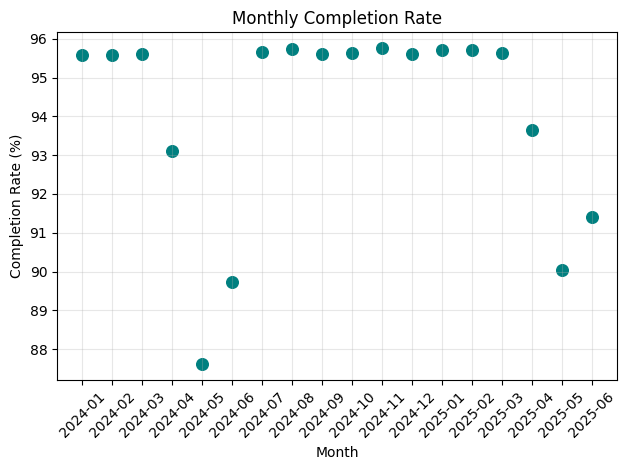

In [28]:
plt.scatter(
    network_monthly["event_month"],
    network_monthly["completion_rate_pct"],
    color="teal",
    s=70,
)

plt.title("Monthly Completion Rate")
plt.xlabel("Month")
plt.ylabel("Completion Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

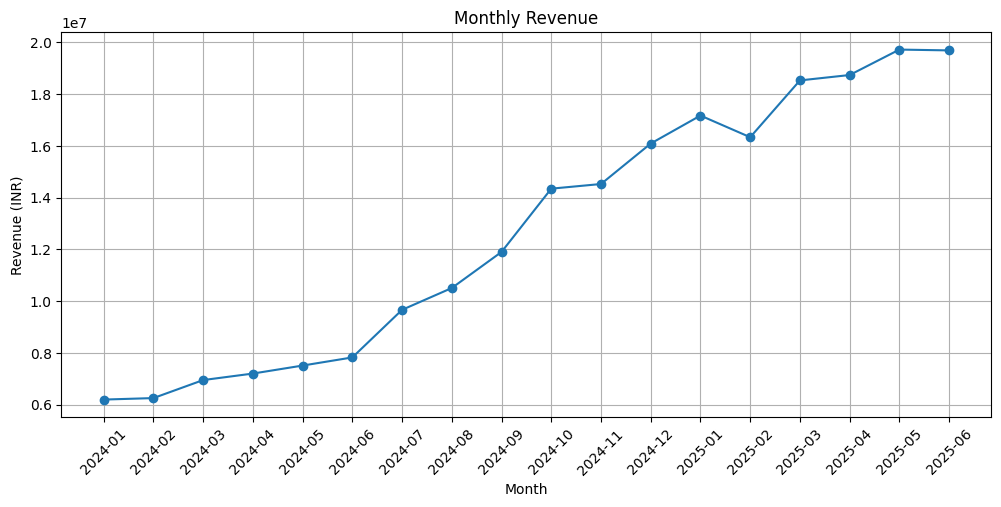

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    network_monthly["event_month"],
    network_monthly["revenue_inr"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Key Findings

- Swap volume increased significantly over the analysis period.
- Revenue increased along with transaction volume.
- Completion rate was relatively stable early in the period but declined during some later months.
- Failure rate increased during the later period.

# 2. Service Failures and Customer Experience

### Business Question
What types of unsuccessful swap attempts occur most often?

In [30]:
service_data = swaps_clean[
    swaps_clean["is_test_station"] == False
].copy()

failure_summary = (
    service_data[service_data["event_type"] != "swap_completed"]
    ["event_type"]
    .value_counts()
    .reset_index()
)

failure_summary.columns = ["event_type", "attempts"]

failure_summary["percentage"] = (
    failure_summary["attempts"] /
    failure_summary["attempts"].sum()
) * 100

failure_summary

,event_type,attempts,percentage
0,failed_no_charged_battery,132786,58.161160
1,abandoned_queue,67663,29.636849
2,cancelled_by_rider,16458,7.208715
3,failed_system_error,11400,4.993277


In [31]:
hourly_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].copy()

hourly_failure["event_hour"] = hourly_failure["event_ts"].dt.hour

hourly_failure["is_unsuccessful"] = (
    hourly_failure["event_type"] != "swap_completed"
)

hourly_failure = (
    hourly_failure.groupby("event_hour")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

hourly_failure["failure_rate"] = (
    hourly_failure["unsuccessful_attempts"]
    / hourly_failure["total_attempts"] * 100
)

hourly_failure

,event_hour,total_attempts,unsuccessful_attempts,failure_rate
0,0,22049,1231,5.583020
1,1,21852,1219,5.578437
2,2,22040,1230,5.580762
3,3,22143,1216,5.491577
4,4,25007,1316,5.262526
5,5,24829,1335,5.376777
6,6,54829,3056,5.573693
7,7,55237,3079,5.574162
8,8,164731,9377,5.692310
9,9,232619,13006,5.591117


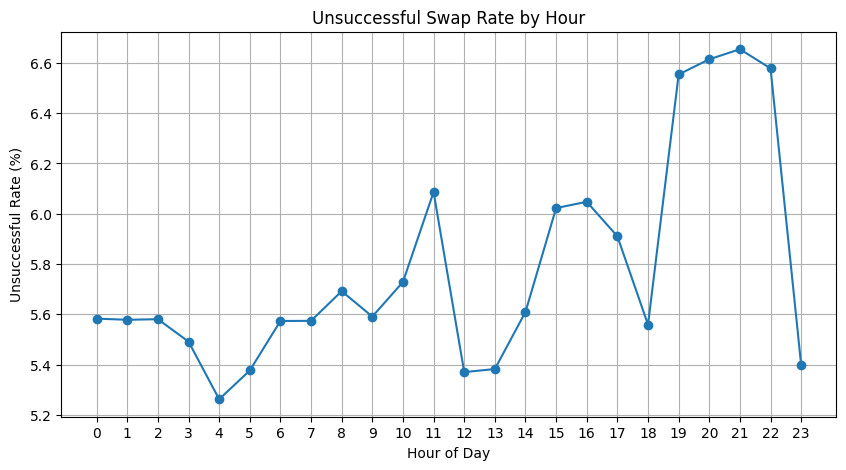

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_failure["event_hour"],
    hourly_failure["failure_rate"],
    marker="o"
)

plt.title("Unsuccessful Swap Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Unsuccessful Rate (%)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [33]:
vehicle_failure = (
    swaps_analysis.groupby("vehicle_class")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

vehicle_failure["unsuccessful_rate"] = (
    vehicle_failure["unsuccessful_attempts"]
    / vehicle_failure["total_attempts"] * 100
)

vehicle_failure.round(2)

,vehicle_class,total_attempts,unsuccessful_attempts,unsuccessful_rate
0,2W,3399568,185157,5.45
1,3W,415414,43150,10.39


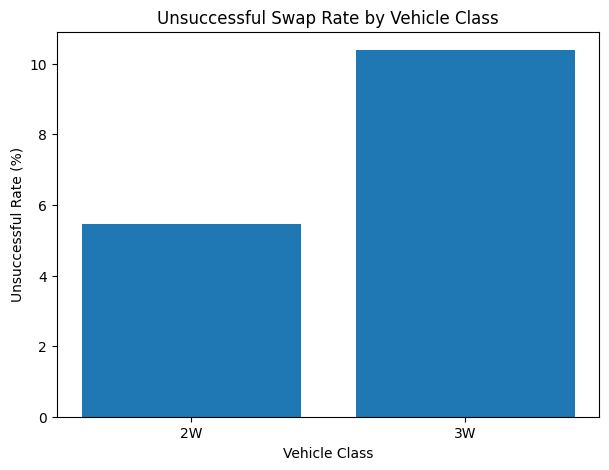

In [34]:
plt.figure(figsize=(7,5))

plt.bar(
    vehicle_failure["vehicle_class"],
    vehicle_failure["unsuccessful_rate"]
)

plt.title("Unsuccessful Swap Rate by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Unsuccessful Rate (%)")

plt.show()

In [35]:

# failure rate by city.
city_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_failure["is_unsuccessful"] = (
    city_failure["event_type"] != "swap_completed"
)

city_failure = (
    city_failure.groupby("city")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

city_failure["unsuccessful_rate"] = (
    city_failure["unsuccessful_attempts"]
    / city_failure["total_attempts"] * 100
)

city_failure.sort_values("unsuccessful_rate", ascending=False).round(2)


,city,total_attempts,unsuccessful_attempts,unsuccessful_rate
3,Jaipur,487634,38268,7.85
1,Delhi NCR,768913,56528,7.35
2,Hyderabad,711930,47618,6.69
5,Pune,552910,27579,4.99
0,Bengaluru,763296,34733,4.55
4,Mumbai,530299,23581,4.45


In [36]:

# failure rate by city.
city_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_failure["is_unsuccessful"] = (
    city_failure["event_type"] != "swap_completed"
)

city_failure = (
    city_failure.groupby("city")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

city_failure["unsuccessful_rate"] = (
    city_failure["unsuccessful_attempts"]
    / city_failure["total_attempts"] * 100
)

city_failure.sort_values("unsuccessful_rate", ascending=False).round(2)

,city,total_attempts,unsuccessful_attempts,unsuccessful_rate
3,Jaipur,487634,38268,7.85
1,Delhi NCR,768913,56528,7.35
2,Hyderabad,711930,47618,6.69
5,Pune,552910,27579,4.99
0,Bengaluru,763296,34733,4.55
4,Mumbai,530299,23581,4.45


In [37]:
# failure rate by station

station_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].groupby("station_id").agg(
    total_attempts=("event_id", "count"),
    unsuccessful_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

station_failure["unsuccessful_rate"] = (
    station_failure["unsuccessful_attempts"]
    / station_failure["total_attempts"] * 100
)

station_failure = station_failure[
    station_failure["total_attempts"] >= 1000
]

station_failure.sort_values(
    "unsuccessful_rate",
    ascending=False
).head(10).round(2)

,station_id,total_attempts,unsuccessful_attempts,unsuccessful_rate
36,STN-DEL-037,30838,2799,9.08
47,STN-DEL-048,34646,3111,8.98
92,STN-JAI-137,44371,3881,8.75
97,STN-JAI-142,33319,2914,8.75
96,STN-JAI-141,45594,3981,8.73
44,STN-DEL-045,32237,2811,8.72
91,STN-JAI-136,29340,2555,8.71
93,STN-JAI-138,48945,4242,8.67
39,STN-DEL-040,40335,3487,8.65
49,STN-DEL-050,47060,4053,8.61


In [38]:

# Failure rate by station location type

location_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].merge(
    stations[["station_id", "location_type"]],
    on="station_id",
    how="left"
)

location_failure["is_unsuccessful"] = (
    location_failure["event_type"] != "swap_completed"
)

location_summary = (
    location_failure.groupby("location_type")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

location_summary["unsuccessful_rate"] = (
    location_summary["unsuccessful_attempts"]
    / location_summary["total_attempts"] * 100
)

location_summary.sort_values(
    "unsuccessful_rate",
    ascending=False
).round(2)

,location_type,total_attempts,unsuccessful_attempts,unsuccessful_rate
2,market,1246931,77752,6.24
0,commercial_hub,1535743,94884,6.18
5,transit_hub,172667,10302,5.97
3,residential,382274,20827,5.45
4,tech_park,147533,7690,5.21
1,highway_fuel_pump,329834,16852,5.11


Key Findings – Station & Geographic Patterns

- Failure rates varied noticeably across cities and stations, with **Jaipur and Delhi NCR** showing higher unsuccessful swap rates.
- **Gen1 chargers** had a higher failure rate than newer charger generations.
- Some individual stations showed consistently higher failure rates, indicating uneven operational performance across the network
- Business Recommendations

- Prioritize high-failure stations for operational review and maintenance.
- Review older Gen1 charger locations for possible upgrades.

Does battery health relate to the distance covered between swaps?


In [39]:
charger_failure = swaps_clean[
    ~swaps_clean["is_test_station"]
].merge(
    stations[["station_id", "charger_generation"]],
    on="station_id",
    how="left"
)

charger_failure["is_unsuccessful"] = (
    charger_failure["event_type"] != "swap_completed"
)

charger_summary = (
    charger_failure.groupby("charger_generation")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

charger_summary["unsuccessful_rate"] = (
    charger_summary["unsuccessful_attempts"]
    / charger_summary["total_attempts"] * 100
)

charger_summary.round(2)

,charger_generation,total_attempts,unsuccessful_attempts,unsuccessful_rate
0,Gen1,1822034,131736,7.23
1,Gen2,1620707,78548,4.85
2,Gen3,372241,18023,4.84


In [40]:
# Failure rate by expansion wave
expansion_analysis = swaps_clean[
    ~swaps_clean["is_test_station"]
].merge(
    stations[["station_id", "expansion_wave"]],
    on="station_id",
    how="left"
)

expansion_analysis["is_unsuccessful"] = (
    expansion_analysis["event_type"] != "swap_completed"
)

expansion_summary = (
    expansion_analysis.groupby("expansion_wave")
    .agg(
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum")
    )
    .reset_index()
)

expansion_summary["unsuccessful_rate"] = (
    expansion_summary["unsuccessful_attempts"]
    / expansion_summary["total_attempts"] * 100
)

expansion_summary.round(2)

,expansion_wave,total_attempts,unsuccessful_attempts,unsuccessful_rate
0,Launch,3068824,191620,6.24
1,Wave1_2024H2,501098,24467,4.88
2,Wave2_2025H1,245060,12220,4.99


Battery & Equipment Performance


In [41]:
# Does battery health relate to delivered range?
battery_analysis = swaps_clean[
    swaps_clean["soh_in_pct"].notna() &
    swaps_clean["km_since_last_swap"].notna()
].copy()

battery_analysis["soh_band"] = pd.cut(
    battery_analysis["soh_in_pct"],
    bins=[0, 80, 90, 95, 100],
    labels=["<80%", "80-90%", "90-95%", "95-100%"]
)

battery_summary = (
    battery_analysis.groupby("soh_band", observed=True)
    .agg(
        swaps=("event_id", "count"),
        avg_km=("km_since_last_swap", "mean")
    )
    .reset_index()
)

battery_summary.round(2)


,soh_band,swaps,avg_km
0,<80%,428530,44.43
1,80-90%,1640932,58.08
2,90-95%,980087,68.21
3,95-100%,788020,72.82


Does observed battery performance differ across suppliers?


In [42]:
# BATTERY SUPPLIER COMPARISON
# battery_in_id identifies the battery returned by the rider.
supplier_analysis = swaps_clean[
    [
        "event_id",
        "battery_in_id",
        "soh_in_pct",
        "km_since_last_swap"
    ]
].copy()

# Keep only records where the battery and performance
# information is available.
supplier_analysis = supplier_analysis[
    supplier_analysis["battery_in_id"].notna() &
    supplier_analysis["km_since_last_swap"].notna()
]

# Add supplier information from the batteries table.
supplier_analysis = supplier_analysis.merge(
    batteries[
        ["battery_id", "supplier"]
    ],
    left_on="battery_in_id",
    right_on="battery_id",
    how="left",
    validate="many_to_one"
)

# Compare battery performance across suppliers.
supplier_summary = (
    supplier_analysis
    .groupby("supplier")
    .agg(
        observed_swaps=("event_id", "count"),
        avg_soh_pct=("soh_in_pct", "mean"),
        avg_km_between_swaps=("km_since_last_swap", "mean")
    )
    .reset_index()
)

# Round the values to make the table easier to read.
supplier_summary[
    ["avg_soh_pct", "avg_km_between_swaps"]
] = supplier_summary[
    ["avg_soh_pct", "avg_km_between_swaps"]
].round(2)

# Display the supplier comparison.
supplier_summary


,supplier,observed_swaps,avg_soh_pct,avg_km_between_swaps
0,Amptek,799050,90.09,64.76
1,Cellora,2182322,90.05,64.45
2,Kyron,859545,81.62,54.04


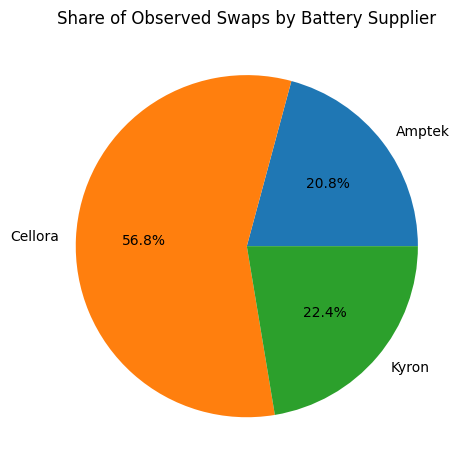

In [43]:
supplier_summary.set_index("supplier")["observed_swaps"].plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel="",
    title="Share of Observed Swaps by Battery Supplier",
)
plt.tight_layout()
plt.show()


Key Findings – Battery & Equipment Performance

- Battery health was strongly associated with distance between swaps: higher-SOH batteries delivered higher average distance.
- Batteries with **95–100% SOH averaged about 72.8 km**, compared with **44.4 km for batteries below 80% SOH**.
- This indicates that battery degradation is associated with lower observed range.

Business Recommendations

- Monitor low-SOH batteries closely and prioritize them for maintenance or replacement.
- Track battery health alongside delivered range as a regular equipment KPI.

Pricing & Partner Economics

In [44]:
# We compare swap volume and revenue across different tariff types to understand how pricing relates to transaction volume and revenue per completed swap.
pricing_summary = (
    swaps_clean[
        ~swaps_clean["is_test_station"]
    ]
    .groupby("tariff_code")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        revenue=("amount_charged_inr", "sum")
    )
    .reset_index()
)

pricing_summary["revenue_per_completed_swap"] = (
    pricing_summary["revenue"] /
    pricing_summary["completed_swaps"]
)

pricing_summary.round(2)

,tariff_code,attempts,completed_swaps,revenue,revenue_per_completed_swap
0,OFFPEAK,36388,34833,2071886.0,59.48
1,PARTNER,2521737,2368154,146079774.5,61.69
2,PEAK,171696,163922,13523775.0,82.50
3,STD,1085161,1019766,67519860.0,66.21


PEAK swaps generated the highest revenue per completed swap, while PARTNER swaps contributed the largest transaction volume. This comparison shows differences in revenue by pricing type, but it does not represent profit because operating costs are not included.

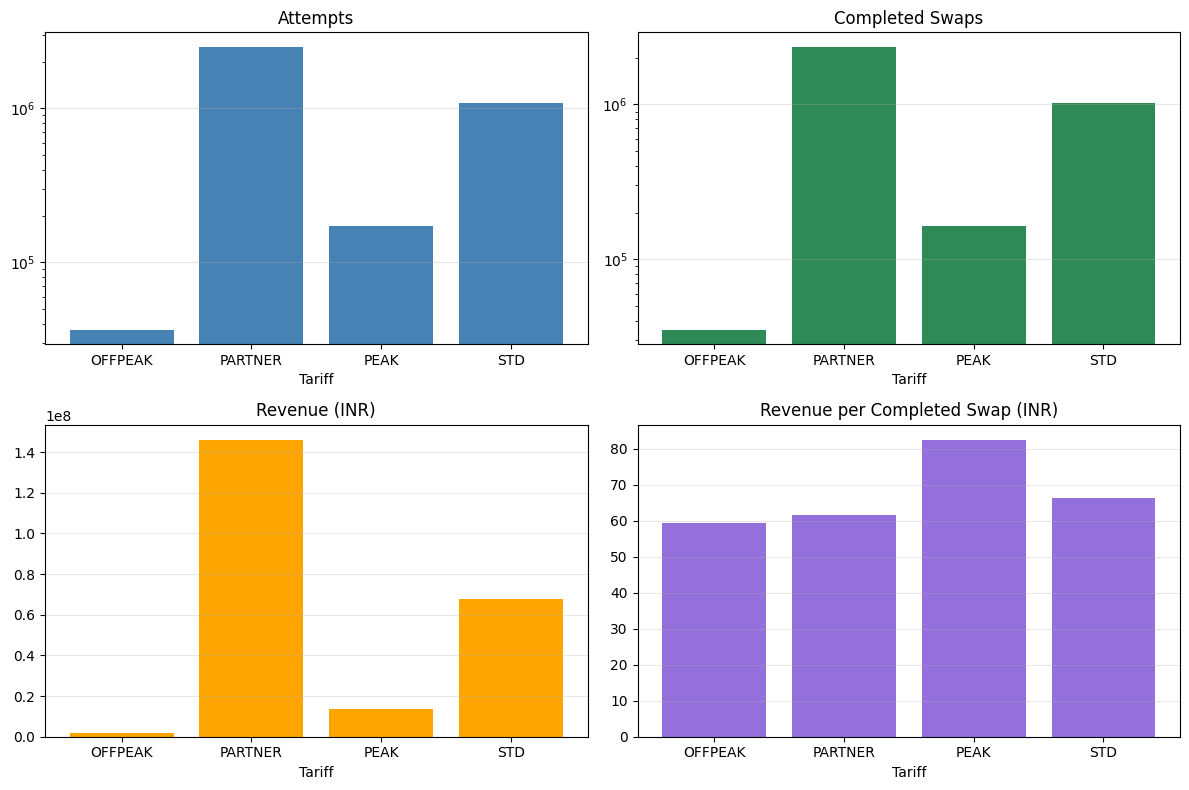

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
tariffs = pricing_summary["tariff_code"]

charts = [
    ("attempts", "Attempts", "steelblue"),
    ("completed_swaps", "Completed Swaps", "seagreen"),
    ("revenue", "Revenue (INR)", "orange"),
    ("revenue_per_completed_swap", "Revenue per Completed Swap (INR)", "mediumpurple"),
]

for ax, (column, title, color) in zip(axes.flat, charts):
    ax.bar(tariffs, pricing_summary[column], color=color)
    ax.set_title(title)
    ax.set_xlabel("Tariff")
    ax.grid(axis="y", alpha=0.3)

# PARTNER is much larger than the other tariffs for these two counts
axes[0, 0].set_yscale("log")
axes[0, 1].set_yscale("log")

plt.tight_layout()
plt.show()

In [46]:
#Fleet Partner Analysis

# We compare fleet partners by completed swap volume, revenue, and contracted discount to understand differences in partner economics.
partner_analysis = (
    swaps_clean[
        ~swaps_clean["is_test_station"]
    ][["event_id", "rider_id", "event_type", "amount_charged_inr"]]
    .merge(
        riders[["rider_id", "partner_id"]],
        on="rider_id",
        how="left"
    )
    .merge(
        partners[["partner_id", "discount_pct"]],
        on="partner_id",
        how="left"
    )
)

partner_summary = (
    partner_analysis[
        partner_analysis["partner_id"].notna()
    ]
    .groupby("partner_id")
    .agg(
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        revenue=("amount_charged_inr", "sum"),
        discount_pct=("discount_pct", "first")
    )
    .reset_index()
)

partner_summary["revenue_per_completed_swap"] = (
    partner_summary["revenue"] /
    partner_summary["completed_swaps"]
)

partner_summary.sort_values(
    "completed_swaps",
    ascending=False
).round(2)

,partner_id,completed_swaps,revenue,discount_pct,revenue_per_completed_swap
2,FP-03,549390,28606514.80,12.0,52.07
0,FP-01,516367,32027884.50,10.0,62.03
1,FP-02,296209,16740212.75,15.0,56.51
4,FP-05,237632,14092428.90,11.0,59.30
3,FP-04,131334,13062630.80,8.0,99.46
6,FP-07,127961,7934508.55,9.0,62.01
5,FP-06,119503,7494595.50,6.0,62.71
7,FP-08,92027,5853723.60,8.0,63.61
11,FP-12,82363,5226978.50,5.0,63.46
9,FP-10,81916,4831146.40,12.0,58.98


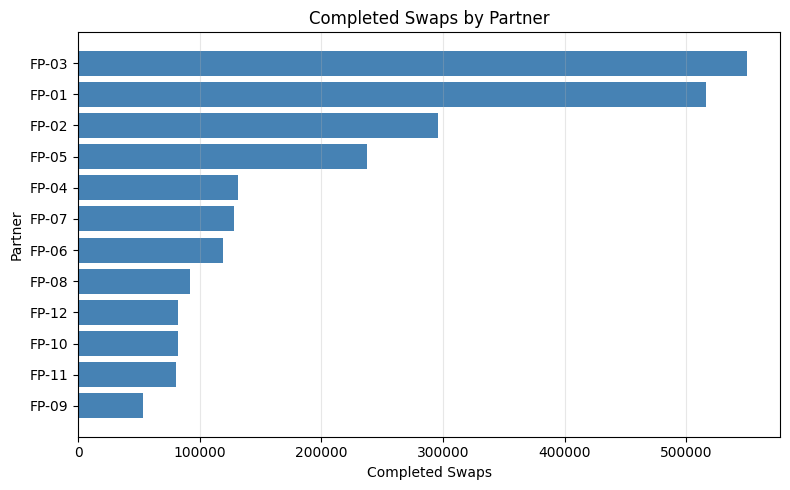

In [47]:
plot_data = partner_summary.sort_values("completed_swaps")

plt.figure(figsize=(8, 5))
plt.barh(plot_data["partner_id"], plot_data["completed_swaps"], color="steelblue")

plt.title("Completed Swaps by Partner")
plt.xlabel("Completed Swaps")
plt.ylabel("Partner")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Key Findings – Pricing & Partner Economics

- **PEAK tariff** generated the highest revenue per completed swap at **₹82.50**, while **PARTNER** had the largest transaction volume.
- Fleet partners varied significantly in revenue per completed swap, showing different revenue patterns across contracts.
- Revenue differences across tariffs and partners should not be interpreted as profit because contribution costs were not calculated.


Business Recommendations

- Monitor pricing performance together with swap volume, not revenue per swap alone.
- Review partner contract terms where high transaction volume is combined with lower revenue per completed swap.

Rider Retention / Churn.

We define a rider's first successful swap as their first completed transaction.
A rider is considered retained if they complete another swap within 30 days.


In [48]:
# Identifying new riders and whether they returned
rider_usage = (
    swaps_clean.groupby("rider_id")
    .agg(
        total_swaps=("event_id", "count"),
        first_swap=("event_ts", "min"),
        last_swap=("event_ts", "max")
    )
    .reset_index()
)

rider_usage["returned"] = rider_usage["total_swaps"] > 1

rider_usage["returned"].value_counts()


returned
True     19868
False       82
Name: count, dtype: int64

In [49]:
completed = swaps_clean[
    (swaps_clean["event_type"] == "swap_completed") &
    (~swaps_clean["is_test_station"])
].copy()

completed.shape

(3586675, 23)

In [50]:
# Finding each rider's first completed swap
first_swap = (
    completed.groupby("rider_id")["event_ts"]
    .min()
    .reset_index()
)

first_swap.columns = ["rider_id", "first_completed_swap"]

first_swap.head()

,rider_id,first_completed_swap
0,RD-1000000,2024-01-03 10:51:42
1,RD-1000001,2024-01-03 12:43:26
2,RD-1000002,2024-01-03 09:24:12
3,RD-1000003,2024-01-01 11:10:56
4,RD-1000004,2024-01-01 17:13:06


In [51]:
# Removing riders who don't have a full 30-day observation window
analysis_end = completed["event_ts"].max()

eligible_riders = first_swap[
    first_swap["first_completed_swap"] <=
    analysis_end - pd.Timedelta(days=30)
].copy()

eligible_riders.shape

(18693, 2)

In [52]:
# Check whether each rider returned within 30 days
retention_check = completed.merge(
    eligible_riders,
    on="rider_id",
    how="inner"
)

retention_check["days_after_first"] = (
    retention_check["event_ts"] -
    retention_check["first_completed_swap"]
).dt.days

retention_30d = (
    retention_check[
        (retention_check["days_after_first"] > 0) &
        (retention_check["days_after_first"] <= 30)
    ]
    .groupby("rider_id")
    .size()
    .reset_index(name="return_swaps")
)

retention_30d["retained_30d"] = True

In [53]:
# Creating the final retention table
retention = eligible_riders.merge(
    retention_30d[["rider_id", "retained_30d"]],
    on="rider_id",
    how="left"
)

retention["retained_30d"] = (
    retention["retained_30d"]
    .fillna(False)
)

retention["retained_30d"].value_counts()

C:\Users\91879\AppData\Local\Temp\ipykernel_17704\732981232.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


retained_30d
True     18570
False      123
Name: count, dtype: int64

In [54]:
# retention by month
retention["first_swap_month"] = (
    retention["first_completed_swap"].dt.to_period("M")
)

monthly_retention = (
    retention.groupby("first_swap_month")
    .agg(
        new_riders=("rider_id", "count"),
        retained_riders=("retained_30d", "sum")
    )
    .reset_index()
)

monthly_retention["retention_rate"] = (
    monthly_retention["retained_riders"]
    / monthly_retention["new_riders"] * 100
)

monthly_retention.round(2)

,first_swap_month,new_riders,retained_riders,retention_rate
0,2024-01,4179,4172,99.83
1,2024-02,569,566,99.47
2,2024-03,599,590,98.50
3,2024-04,661,652,98.64
4,2024-05,715,709,99.16
5,2024-06,716,710,99.16
6,2024-07,805,801,99.50
7,2024-08,855,851,99.53
8,2024-09,871,863,99.08
9,2024-10,1188,1182,99.49


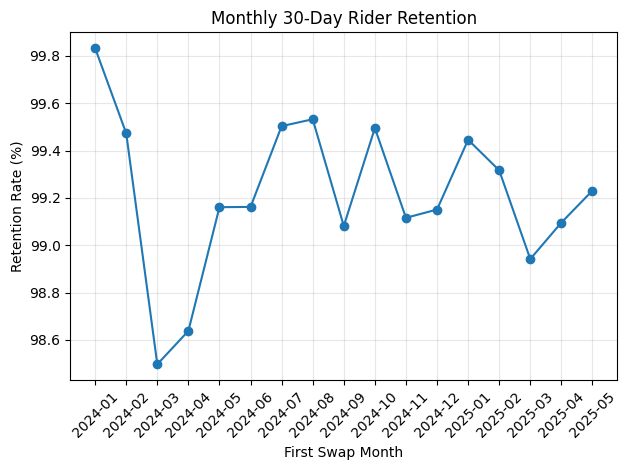

In [55]:
plt.plot(
    monthly_retention["first_swap_month"].astype(str),
    monthly_retention["retention_rate"],
    marker="o",
)

plt.title("Monthly 30-Day Rider Retention")
plt.xlabel("First Swap Month")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:

# FIRST 30-DAY EXPERIENCE: RETAINED VS NON-RETAINED

retention_experience = retention[
    ["rider_id", "first_completed_swap", "retained_30d"]
].copy()

retention_experience = retention_experience.merge(
    swaps_analysis,
    on="rider_id",
    how="left"
)

# Keep only events that happened during the first 30 days
# after the rider's first completed swap.
retention_experience = retention_experience[
    (retention_experience["event_ts"] >= retention_experience["first_completed_swap"]) &
    (retention_experience["event_ts"] <=
     retention_experience["first_completed_swap"] + pd.Timedelta(days=30))
].copy()

# Mark unsuccessful attempts.
retention_experience["is_unsuccessful"] = (
    retention_experience["event_type"] != "swap_completed"
)

# Compare the experience of retained and non-retained riders.
retention_summary = (
    retention_experience
    .groupby("retained_30d")
    .agg(
        riders=("rider_id", "nunique"),
        total_attempts=("event_id", "count"),
        unsuccessful_attempts=("is_unsuccessful", "sum"),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

# Calculate failure rate.
retention_summary["failure_rate_%"] = (
    retention_summary["unsuccessful_attempts"]
    / retention_summary["total_attempts"]
    * 100
).round(2)

# Convert queue wait from seconds to minutes.
retention_summary["avg_queue_wait_min"] = (
    retention_summary["avg_queue_wait_sec"] / 60
).round(2)

# Give readable labels to the retention groups.
retention_summary["retention_group"] = (
    retention_summary["retained_30d"]
    .map({
        True: "Returned within 30 days",
        False: "Did not return within 30 days"
    })
)

# Show only the important business metrics.
retention_summary[
    [
        "retention_group",
        "riders",
        "total_attempts",
        "failure_rate_%",
        "avg_queue_wait_min"
    ]
]

,retention_group,riders,total_attempts,failure_rate_%,avg_queue_wait_min
0,Did not return within 30 days,123,194,6.70,4.27
1,Returned within 30 days,18570,531370,5.37,4.04


Key Findings – Rider Retention

- Monthly 30-day retention remained very high across the analyzed cohorts, generally above **98%**.
- Riders who did not return had a slightly higher unsuccessful-attempt rate (**6.70% vs. 5.37%**) and longer average queue wait (**4.27 vs. 4.04 minutes**).
- This suggests that a poorer initial service experience is associated with lower 30-day return.

 Business Recommendations

- Monitor new riders' first-30-day service experience, especially failed attempts and queue wait.
- Focus on reducing early service issues that may affect rider return.

Service Failures & Customer Experience.
how many support tickets fall into each complaint category
what percentage of all tickets each category represents

In [57]:

# SUPPORT TICKET COMPLAINT ANALYSIS
# Count the number of support tickets in each complaint category.
ticket_category_summary = (
    tickets_clean
    .groupby('category')
    .agg(
        ticket_count=('ticket_id', 'count')
    )
    .reset_index()
)

# Calculate the percentage of total tickets for each category.
ticket_category_summary['ticket_share_%'] = (
    ticket_category_summary['ticket_count']
    / ticket_category_summary['ticket_count'].sum()
    * 100
).round(2)

# Sort from highest number of complaints to lowest.
ticket_category_summary = ticket_category_summary.sort_values(
    'ticket_count',
    ascending=False
)

ticket_category_summary

,category,ticket_count,ticket_share_%
4,no_battery_available,11647,26.47
5,other,9484,21.55
3,low_range,6636,15.08
0,app_issue,5787,13.15
2,long_queue,5731,13.02
1,billing_dispute,4715,10.72


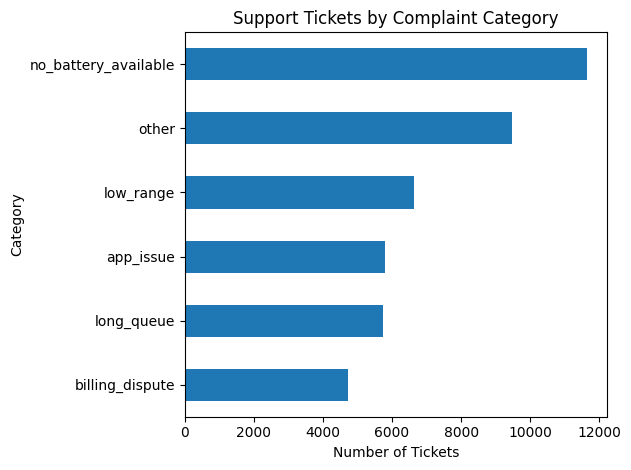

In [58]:
ticket_category_summary.sort_values("ticket_count").plot(
    x="category",
    y="ticket_count",
    kind="barh",
    legend=False,
    title="Support Tickets by Complaint Category",
    xlabel="Number of Tickets",
    ylabel="Category",
)

plt.tight_layout()
plt.show()


Key Findings – Customer Support Complaints

- **No battery available** was the largest complaint category, accounting for **26.47%** of all support tickets.
- **Low range (15.08%)** and **long queues (13.02%)** were also major customer complaints.
- This supports the operational finding that **battery availability and service delays are important customer-experience issues**.

Business Recommendations

- Improve battery availability at frequently affected stations.
- Monitor queue times and address locations with repeated customer complaints.

Overall Key Findings

- Network volume and revenue increased significantly, but service reliability declined during later periods.
- **Lack of charged batteries** was the largest operational failure, and failures were higher in some cities, stations, and older Gen1 chargers.
- Battery health was strongly associated with observed range, with higher-SOH batteries covering more kilometres between swaps.
- Pricing and partner segments showed different revenue patterns, while customer complaints were concentrated around **battery availability, range, and queues**.
- Riders who did not return within 30 days experienced slightly higher failure rates and queue waits during their initial usage.

Overall Business Recommendations

- Improve battery availability and service reliability at high-failure locations.
- Prioritize low-SOH batteries and older Gen1 chargers for monitoring and maintenance.
- Monitor pricing and partner performance using both volume and revenue per completed swap.
- Focus on improving the first-30-day rider experience by reducing failures and waiting time.